from pathlib import Path


def create_model_card(
    output_path="model_card.md",
    model_name="Logistic Regression",
    purpose="Adult Income classification",
    training_data="UCI Adult Income dataset",
    performance=None,
    fairness=None,
    explainability="SHAP",
    limitations=None,
    ethical_considerations=None
):
    """
    Generate a simple Responsible AI model card.
    """

    performance = performance or {}
    fairness = fairness or {}
    limitations = limitations or []
    ethical_considerations = ethical_considerations or []

    performance_text = "\n".join(
        [
            f"- **{key}:** {value:.4f}"
            if isinstance(value, (float, int))
            else f"- **{key}:** {value}"
            for key, value in performance.items()
        ]
    )

    fairness_text = "\n".join(
        [
            f"- **{key}:** {value:.4f}"
            if isinstance(value, (float, int))
            else f"- **{key}:** {value}"
            for key, value in fairness.items()
        ]
    )

    limitations_text = "\n".join(
        f"- {item}" for item in limitations
    )

    ethics_text = "\n".join(
        f"- {item}" for item in ethical_considerations
    )

    content = f"""# Model Card — {model_name}

## 1. Model Details

**Model:** {model_name}

**Framework:** Scikit-learn

**Version:** 1.0

---

## 2. Intended Use

{purpose}

This model is intended for educational and analytical purposes.
It should not be used as an automated high-stakes decision system.

---

## 3. Training Data

**Dataset:** {training_data}

The model was evaluated with gender as a protected attribute
for Responsible AI fairness analysis.

---

## 4. Model Performance

{performance_text}

---

## 5. Fairness Analysis

{fairness_text}

Fairness metrics were calculated using IBM AI Fairness 360.

---

## 6. Explainability

**Method:** {explainability}

SHAP explanations were generated to understand the contribution
of individual features to model predictions.

---

## 7. Ethical Considerations

{ethics_text}

---

## 8. Limitations

{limitations_text}

---

## 9. Conclusion

The model should be evaluated not only using predictive performance
but also using fairness and explainability measures before any
real-world deployment.
"""

    Path(output_path).write_text(
        content,
        encoding="utf-8"
    )

    print(f"Model card saved to: {output_path}")

    return content

In [1]:
import sys
import os
import json
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing

import shap

# Allow imports from src/utils
PROJECT_ROOT = os.path.abspath(
    os.path.join(os.getcwd(), "../..")
)

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.utils.bias_audit import detect_bias
from src.utils.fairness_metrics import compute_fairness
from src.utils.shap_explain import run_shap
from src.utils.model_card import create_model_card

print("Libraries imported successfully.")

pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


Libraries imported successfully.


In [2]:
import urllib.request

DATA_DIR = os.path.join(PROJECT_ROOT, "src", "data")
os.makedirs(DATA_DIR, exist_ok=True)

data_path = os.path.join(
    DATA_DIR,
    "loan_data.csv"
)

adult_url = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "adult/adult.data"
)

urllib.request.urlretrieve(
    adult_url,
    data_path
)

print("Dataset downloaded:")
print(data_path)

Dataset downloaded:
c:\Users\Monika\CynarisInternship\AI-ML-Project\W4D6-responsible_ai_demo\src\data\loan_data.csv


In [3]:
columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

df = pd.read_csv(
    data_path,
    names=columns,
    skipinitialspace=True
)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
# Remove whitespace
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

# Replace missing markers
df = df.replace("?", np.nan)

# Drop missing rows
df = df.dropna().reset_index(drop=True)

# Convert target to binary
df["income_binary"] = (
    df["income"]
    .str.replace(".", "", regex=False)
    .eq(">50K")
    .astype(int)
)

# Convert gender to binary
# Female = 0 → unprivileged
# Male = 1 → privileged
df["sex_binary"] = (
    df["sex"]
    .eq("Male")
    .astype(int)
)

print("Cleaned shape:", df.shape)

df[["sex", "sex_binary", "income", "income_binary"]].head()

Cleaned shape: (30162, 17)


,sex,sex_binary,income,income_binary
0,Male,1,<=50K,0
1,Male,1,<=50K,0
2,Male,1,<=50K,0
3,Male,1,<=50K,0
4,Female,0,<=50K,0


In [5]:
# Remove whitespace
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

# Replace missing markers
df = df.replace("?", np.nan)

# Drop missing rows
df = df.dropna().reset_index(drop=True)

# Convert target to binary
df["income_binary"] = (
    df["income"]
    .str.replace(".", "", regex=False)
    .eq(">50K")
    .astype(int)
)

# Convert gender to binary
# Female = 0 → unprivileged
# Male = 1 → privileged
df["sex_binary"] = (
    df["sex"]
    .eq("Male")
    .astype(int)
)

print("Cleaned shape:", df.shape)

df[["sex", "sex_binary", "income", "income_binary"]].head()

Cleaned shape: (30162, 17)


,sex,sex_binary,income,income_binary
0,Male,1,<=50K,0
1,Male,1,<=50K,0
2,Male,1,<=50K,0
3,Male,1,<=50K,0
4,Female,0,<=50K,0


In [6]:
gender_distribution = (
    df["sex"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Gender distribution (%):")
print(gender_distribution)

Gender distribution (%):
sex
Male      67.57
Female    32.43
Name: proportion, dtype: float64


In [7]:
bias_report = detect_bias(
    df,
    protected_cols=["sex"]
)

display(bias_report)

,protected_attribute,bias_type,group,count,percentage,finding,severity
0,sex,Representation bias,Male,20380,67.57,Group represents 67.57% of the dataset,Low
1,sex,Representation bias,Female,9782,32.43,Group represents 32.43% of the dataset,Low
2,sex,Measurement bias,All,0,0.00,0 missing values detected,Low
3,sex,Sampling bias,All,30162,100.00,Requires comparison with the target real-world...,Review
4,sex,Historical bias,All,30162,100.00,Requires checking whether historical outcomes ...,Review
5,sex,Label bias,All,30162,100.00,Requires checking whether target labels were c...,Review
6,sex,Aggregation bias,All,30162,100.00,Check whether one model is being applied to he...,Review


In [8]:
bias_report_path = os.path.join(
    PROJECT_ROOT,
    "bias_report.csv"
)

bias_report.to_csv(
    bias_report_path,
    index=False
)

print(f"Bias report saved to: {bias_report_path}")

Bias report saved to: c:\Users\Monika\CynarisInternship\AI-ML-Project\W4D6-responsible_ai_demo\bias_report.csv


In [9]:
target = "income_binary"

protected_attribute = "sex_binary"

feature_columns = [
    "age",
    "workclass",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country"
]

X = df[feature_columns].copy()
y = df[target].copy()

protected = df[protected_attribute].copy()

print("Features:", X.shape)
print("Target:", y.shape)
print("Protected attribute:", protected.shape)

Features: (30162, 12)
Target: (30162,)
Protected attribute: (30162,)


In [10]:
X_train, X_test, y_train, y_test, protected_train, protected_test = (
    train_test_split(
        X,
        y,
        protected,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 24129
Testing samples: 6033


In [11]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [12]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

baseline_model.fit(
    X_train,
    y_train
)

y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [13]:
baseline_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(
        y_test,
        y_pred,
        zero_division=0
    ),
    "recall": recall_score(
        y_test,
        y_pred,
        zero_division=0
    ),
    "f1": f1_score(
        y_test,
        y_pred,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_test,
        y_prob
    )
}

print("Baseline Performance")

for metric, value in baseline_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Baseline Performance
accuracy: 0.8457
precision: 0.7304
recall: 0.6025
f1: 0.6603
roc_auc: 0.9013

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      4531
           1       0.73      0.60      0.66      1502

    accuracy                           0.85      6033
   macro avg       0.80      0.76      0.78      6033
weighted avg       0.84      0.85      0.84      6033



In [14]:
fairness_df = pd.DataFrame({
    "sex_binary": protected_test.to_numpy()
})

baseline_fairness = compute_fairness(
    y_true=y_test.to_numpy(),
    y_pred=y_pred,
    df=fairness_df,
    protected_attribute="sex_binary"
)

print("Baseline Fairness Metrics:")

for metric, value in baseline_fairness.items():
    print(f"{metric}: {value:.4f}")

Baseline Fairness Metrics:
disparate_impact: 0.3534
equal_opportunity_difference: -0.0635
statistical_parity_difference: -0.1683


In [15]:
baseline_results = {
    "performance": baseline_metrics,
    "fairness": baseline_fairness
}

with open(
    os.path.join(
        PROJECT_ROOT,
        "fairness_metrics_baseline.json"
    ),
    "w"
) as f:
    json.dump(
        baseline_results,
        f,
        indent=4
    )

print("Baseline fairness results saved.")

Baseline fairness results saved.


In [16]:
X_train_transformed = baseline_model.named_steps[
    "preprocessor"
].transform(X_train)

X_test_transformed = baseline_model.named_steps[
    "preprocessor"
].transform(X_test)

classifier = baseline_model.named_steps[
    "classifier"
]

feature_names = baseline_model.named_steps[
    "preprocessor"
].get_feature_names_out()

X_train_shap = pd.DataFrame(
    X_train_transformed.toarray()
    if hasattr(X_train_transformed, "toarray")
    else X_train_transformed,
    columns=feature_names
)

X_test_shap = pd.DataFrame(
    X_test_transformed.toarray()
    if hasattr(X_test_transformed, "toarray")
    else X_test_transformed,
    columns=feature_names
)

print(X_test_shap.shape)

(6033, 101)


In [17]:
shap_dir = os.path.join(
    PROJECT_ROOT,
    "shap_plots"
)

shap_values = run_shap(
    classifier,
    X_train_shap,
    X_test_shap,
    shap_dir
)

Generating SHAP explanations...
Saved: c:\Users\Monika\CynarisInternship\AI-ML-Project\W4D6-responsible_ai_demo\shap_plots\shap_summary.png
Saved: c:\Users\Monika\CynarisInternship\AI-ML-Project\W4D6-responsible_ai_demo\shap_plots\shap_waterfall.png


In [18]:
train_fairness_df = pd.DataFrame({
    "income_binary": y_train.to_numpy(),
    "sex_binary": protected_train.to_numpy()
})

train_dataset = BinaryLabelDataset(
    favorable_label=1,
    unfavorable_label=0,
    df=train_fairness_df,
    label_names=["income_binary"],
    protected_attribute_names=["sex_binary"]
)

privileged_groups = [
    {"sex_binary": 1}
]

unprivileged_groups = [
    {"sex_binary": 0}
]

reweighing = Reweighing(
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

reweighing.fit(train_dataset)

weights_dataset = reweighing.transform(
    train_dataset
)

sample_weights = weights_dataset.instance_weights.ravel()

print("Reweighing completed.")
print("Sample weights:", sample_weights[:10])

Reweighing completed.
Sample weights: [1.09547641 0.79177244 0.84604308 1.09547641 0.84604308 1.09547641
 0.79177244 2.21778692 1.09547641 0.84604308]


In [19]:
mitigated_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

X_train_transformed_rw = mitigated_preprocessor.fit_transform(
    X_train
)

X_test_transformed_rw = mitigated_preprocessor.transform(
    X_test
)

mitigated_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

mitigated_classifier.fit(
    X_train_transformed_rw,
    y_train,
    sample_weight=sample_weights
)

y_pred_rw = mitigated_classifier.predict(
    X_test_transformed_rw
)

y_prob_rw = mitigated_classifier.predict_proba(
    X_test_transformed_rw
)[:, 1]

print("Mitigated model trained.")

Mitigated model trained.


In [20]:
mitigated_metrics = {
    "accuracy": accuracy_score(
        y_test,
        y_pred_rw
    ),
    "precision": precision_score(
        y_test,
        y_pred_rw,
        zero_division=0
    ),
    "recall": recall_score(
        y_test,
        y_pred_rw,
        zero_division=0
    ),
    "f1": f1_score(
        y_test,
        y_pred_rw,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_test,
        y_prob_rw
    )
}

print("Mitigated Performance")

for metric, value in mitigated_metrics.items():
    print(f"{metric}: {value:.4f}")

Mitigated Performance
accuracy: 0.8400
precision: 0.7370
recall: 0.5559
f1: 0.6338
roc_auc: 0.8963


In [21]:
mitigated_fairness = compute_fairness(
    y_true=y_test.to_numpy(),
    y_pred=y_pred_rw,
    df=fairness_df,
    protected_attribute="sex_binary"
)

print("Mitigated Fairness Metrics:")

for metric, value in mitigated_fairness.items():
    print(f"{metric}: {value:.4f}")

Mitigated Fairness Metrics:
disparate_impact: 0.6368
equal_opportunity_difference: 0.1431
statistical_parity_difference: -0.0774


In [22]:
comparison = pd.DataFrame({
    "Metric": [
        "Disparate Impact",
        "Equal Opportunity Difference",
        "Statistical Parity Difference"
    ],
    "Baseline": [
        baseline_fairness["disparate_impact"],
        baseline_fairness[
            "equal_opportunity_difference"
        ],
        baseline_fairness[
            "statistical_parity_difference"
        ]
    ],
    "After Reweighing": [
        mitigated_fairness["disparate_impact"],
        mitigated_fairness[
            "equal_opportunity_difference"
        ],
        mitigated_fairness[
            "statistical_parity_difference"
        ]
    ]
})

display(comparison)

,Metric,Baseline,After Reweighing
0,Disparate Impact,0.353369,0.636838
1,Equal Opportunity Difference,-0.063534,0.143052
2,Statistical Parity Difference,-0.168299,-0.077367


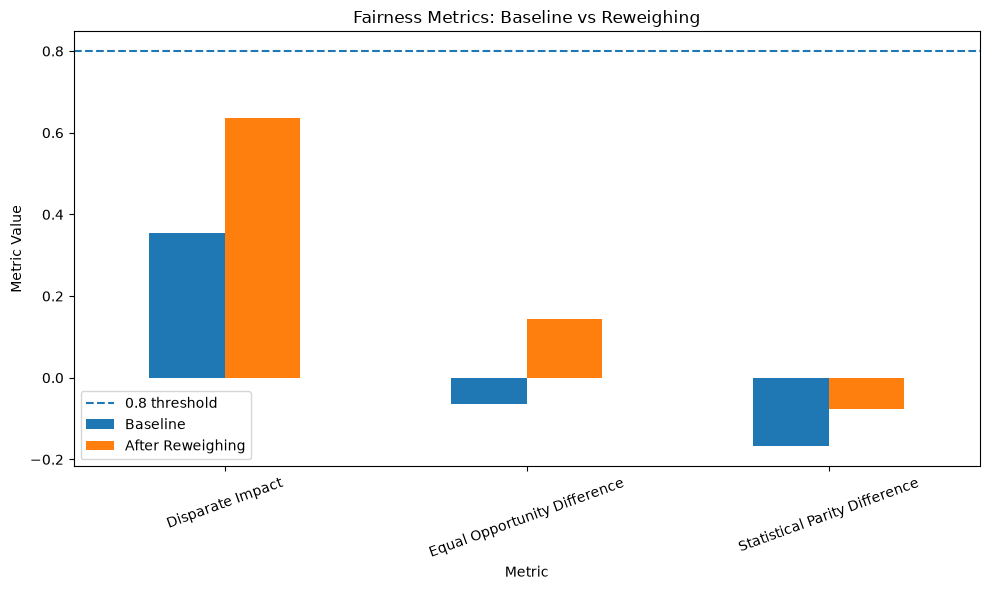

In [23]:
comparison_plot = comparison.set_index(
    "Metric"
)

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.axhline(
    0.8,
    linestyle="--",
    label="0.8 threshold"
)

plt.title(
    "Fairness Metrics: Baseline vs Reweighing"
)

plt.ylabel("Metric Value")
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(
        PROJECT_ROOT,
        "fairness_comparison.png"
    ),
    dpi=300
)

plt.show()

In [24]:
final_results = {
    "baseline": {
        "performance": baseline_metrics,
        "fairness": baseline_fairness
    },
    "after_reweighing": {
        "performance": mitigated_metrics,
        "fairness": mitigated_fairness
    }
}

final_json_path = os.path.join(
    PROJECT_ROOT,
    "fairness_metrics.json"
)

with open(
    final_json_path,
    "w"
) as f:
    json.dump(
        final_results,
        f,
        indent=4
    )

print(
    f"Final fairness results saved to: {final_json_path}"
)

Final fairness results saved to: c:\Users\Monika\CynarisInternship\AI-ML-Project\W4D6-responsible_ai_demo\fairness_metrics.json


In [25]:
model_card_path = os.path.join(
    PROJECT_ROOT,
    "model_card.md"
)

create_model_card(
    output_path=model_card_path,
    model_name="Logistic Regression — Adult Income",
    purpose=(
        "Classify whether an individual's annual income "
        "is above $50K using demographic and employment-related "
        "features."
    ),
    training_data="UCI Adult Income dataset",
    performance=mitigated_metrics,
    fairness=mitigated_fairness,
    explainability="SHAP",
    limitations=[
        "The Adult dataset may contain historical and representation bias.",
        "Fairness metrics depend on the selected protected attribute.",
        "The model should not be used for high-stakes automated decisions.",
        "Removing gender from model features does not completely remove proxy bias."
    ],
    ethical_considerations=[
        "Gender was treated as a protected attribute.",
        "Fairness was evaluated before and after Reweighing.",
        "SHAP was used to improve model transparency."
    ]
)

print("Model card generated.")

Model card saved to: c:\Users\Monika\CynarisInternship\AI-ML-Project\W4D6-responsible_ai_demo\model_card.md
Model card generated.


In [26]:
print("=" * 60)
print("RESPONSIBLE AI FINAL SUMMARY")
print("=" * 60)

print("\nBaseline Performance:")
for key, value in baseline_metrics.items():
    print(f"{key}: {value:.4f}")

print("\nBaseline Fairness:")
for key, value in baseline_fairness.items():
    print(f"{key}: {value:.4f}")

print("\nAfter Reweighing Performance:")
for key, value in mitigated_metrics.items():
    print(f"{key}: {value:.4f}")

print("\nAfter Reweighing Fairness:")
for key, value in mitigated_fairness.items():
    print(f"{key}: {value:.4f}")

print("\nGenerated artifacts:")
print("✓ bias_report.csv")
print("✓ fairness_metrics.json")
print("✓ fairness_comparison.png")
print("✓ shap_plots/shap_summary.png")
print("✓ shap_plots/shap_waterfall.png")
print("✓ model_card.md")

RESPONSIBLE AI FINAL SUMMARY

Baseline Performance:
accuracy: 0.8457
precision: 0.7304
recall: 0.6025
f1: 0.6603
roc_auc: 0.9013

Baseline Fairness:
disparate_impact: 0.3534
equal_opportunity_difference: -0.0635
statistical_parity_difference: -0.1683

After Reweighing Performance:
accuracy: 0.8400
precision: 0.7370
recall: 0.5559
f1: 0.6338
roc_auc: 0.8963

After Reweighing Fairness:
disparate_impact: 0.6368
equal_opportunity_difference: 0.1431
statistical_parity_difference: -0.0774

Generated artifacts:
✓ bias_report.csv
✓ fairness_metrics.json
✓ fairness_comparison.png
✓ shap_plots/shap_summary.png
✓ shap_plots/shap_waterfall.png
✓ model_card.md


In [27]:
print("Baseline Fairness:")
for key, value in baseline_fairness.items():
    print(f"{key}: {value:.4f}")

print("\nAfter Reweighing Fairness:")
for key, value in mitigated_fairness.items():
    print(f"{key}: {value:.4f}")

Baseline Fairness:
disparate_impact: 0.3534
equal_opportunity_difference: -0.0635
statistical_parity_difference: -0.1683

After Reweighing Fairness:
disparate_impact: 0.6368
equal_opportunity_difference: 0.1431
statistical_parity_difference: -0.0774
